# Datathon Passos Mágicos — Análise Exploratória (EDA)
### FIAP PósTech Data Analytics · Fase 5

Base: **PEDE** (Pesquisa Extensiva do Desenvolvimento Educacional), anos **2022, 2023 e 2024**.
Responde as perguntas de negócio 1–8, 10 e 11 e prepara o modelo preditivo de risco (pergunta 9).

Bases (geradas em `src/harmonizacao.py` e `src/modelagem_base.py`):
- `base_tidy.csv` — uma linha por aluno-ano (3.030)
- `base_modelagem.csv` — uma linha por transição N→N+1 (1.365 pares) com rótulos de risco

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
ROXO,VERDE,VERM,AMAR,AZUL='#6b4e9e','#2a9d8f','#e76f51','#e9c46a','#264653'
tidy=pd.read_csv('../data/processed/base_tidy.csv'); mod=pd.read_csv('../data/processed/base_modelagem.csv')
print('base_tidy:',tidy.shape,'| base_modelagem:',mod.shape); tidy.groupby('ano').size()

base_tidy: (3030, 25) | base_modelagem: (1365, 29)


ano
2022     860
2023    1014
2024    1156
dtype: int64

## Q1 — Adequação ao nível (IAN): perfil de defasagem e evolução
`Defasagem = Fase efetiva − Fase ideal` (negativo = atrasado); IAN é a versão normalizada.

In [2]:
def cat(d):
    if d>=0: return 'Adequado/Adiantado'
    if d==-1: return 'Leve (-1)'
    if d in (-2,-3): return 'Moderada (-2 a -3)'
    return 'Severa (<=-4)'
tidy['defas_cat']=tidy['defasagem'].apply(cat)
order=['Adequado/Adiantado','Leve (-1)','Moderada (-2 a -3)','Severa (<=-4)']
(tidy.groupby('ano')['defas_cat'].value_counts(normalize=True).unstack()[order]*100).round(1)

defas_cat,Adequado/Adiantado,Leve (-1),Moderada (-2 a -3),Severa (<=-4)
ano,,,,
2022,30.1,47.7,21.6,0.6
2023,45.6,40.2,14.1,0.1
2024,53.8,38.1,8.0,NaN


**Achado.** Adequados/adiantados sobem de **30,1% (2022) para 53,8% (2024)**; defasagem moderada
cai de 21,6% para 8,0%; casos severos praticamente eliminados (5→1→0). ⚠️ *Leitura cross-sectional
(coorte muda de composição); prova sem viés está na Q10.*

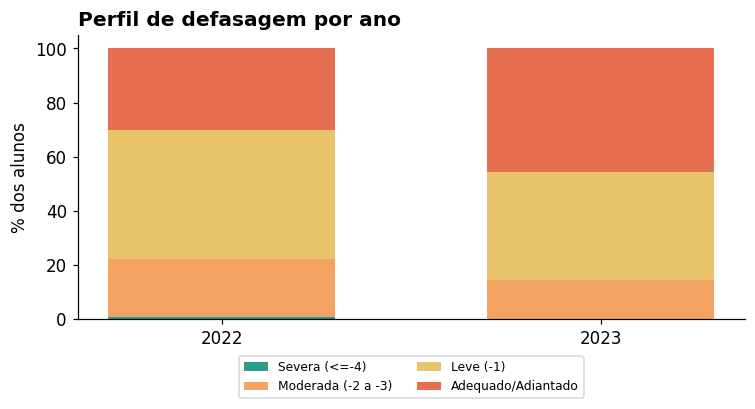

In [3]:
fig,ax=plt.subplots(figsize=(7,4)); o2=order[::-1]; cores=['#2a9d8f','#f4a261','#e9c46a','#e76f51']
tab=(tidy.groupby('ano')['defas_cat'].value_counts(normalize=True).unstack()[o2]*100); bottom=np.zeros(3)
for col,cor in zip(o2,cores):
    ax.bar(tab.index.astype(str),tab[col],bottom=bottom,label=col,color=cor,width=.6); bottom+=tab[col].values
ax.set_ylabel('% dos alunos'); ax.legend(fontsize=8,ncol=2,loc='lower center',bbox_to_anchor=(.5,-.3))
ax.set_title('Perfil de defasagem por ano',loc='left',weight='bold'); plt.tight_layout(); plt.show()

## Q2 — Desempenho acadêmico (IDA)

In [4]:
display(tidy.groupby('ano')['ida'].mean().round(2).rename('IDA médio'))
tidy[tidy.ano==2024].groupby('fase_num')['ida'].mean().round(2).rename('IDA por fase (2024)')

ano
2022    6.09
2023    6.66
2024    6.35
Name: IDA médio, dtype: float64

fase_num
0.0    7.32
1.0    6.79
2.0    6.25
3.0    5.35
4.0    5.88
5.0    6.45
6.0    7.23
7.0    5.81
8.0    8.00
9.0     NaN
Name: IDA por fase (2024), dtype: float64

**Achado.** Agregado sobe e recua (6,09→6,66→6,35). Por fase há um **vale na fase 3 (Fund. II)** —
a transição para a adolescência é o ponto pedagógico mais sensível.

## Q3 e Q4 — Engajamento (IEG), Autoavaliação (IAA) e coerência

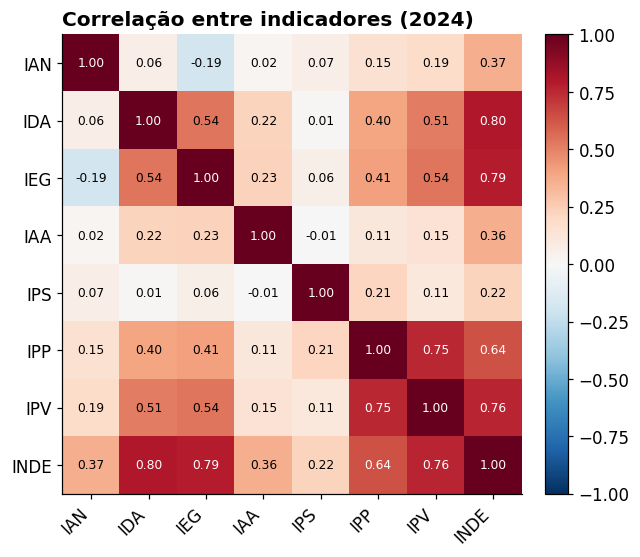

In [5]:
ind=['ian','ida','ieg','iaa','ips','ipp','ipv','inde']; corr=tidy[tidy.ano==2024][ind].corr()
fig,ax=plt.subplots(figsize=(6.2,5.2)); im=ax.imshow(corr,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(len(ind))); ax.set_xticklabels([i.upper() for i in ind],rotation=45,ha='right')
ax.set_yticks(range(len(ind))); ax.set_yticklabels([i.upper() for i in ind])
for i in range(len(ind)):
    for j in range(len(ind)):
        ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8,color='white' if abs(corr.iloc[i,j])>.55 else 'black')
plt.colorbar(im,fraction=.046,pad=.04); plt.title('Correlação entre indicadores (2024)',loc='left',weight='bold'); plt.tight_layout(); plt.show()

**Q3.** IEG relaciona-se com IDA (**r=0,54**) e IPV (**r=0,54**): engajar é a alavanca acadêmica.
**Q4.** IAA é só **fracamente coerente** com o real (IDA 0,22; IEG 0,23): a autoimagem descola da performance.

## Q5 — Aspectos psicossociais (IPS) antecedem quedas?

In [6]:
m=mod[~mod.features_ausentes].copy(); m['ips_baixo']=m['ips']<m['ips'].median()
print(f"IPS baixo em N -> {m[m.ips_baixo]['y_queda_inde'].mean():.1%} caem de INDE em N+1")
print(f"IPS alto em N  -> {m[~m.ips_baixo]['y_queda_inde'].mean():.1%} caem de INDE em N+1")

IPS baixo em N -> 44.2% caem de INDE em N+1
IPS alto em N  -> 47.2% caem de INDE em N+1


**Achado (negativo e honesto).** Sem evidência de que IPS anteceda quedas (44% vs 47%). O IPS é
**ortogonal** aos demais — mede uma dimensão própria.

## Q6 e Q7 — Psicopedagógico (IPP) e Ponto de Virada (IPV)

In [7]:
tidy[['ipv','ida','ieg','iaa','ips','ipp','ian']].corr()['ipv'].drop('ipv').sort_values(ascending=False).round(2)

ipp    0.61
ieg    0.56
ida    0.56
ian    0.15
iaa    0.06
ips   -0.05
Name: ipv, dtype: float64

**Q6.** IPP acompanha IAN e o desempenho — **confirma**, não contradiz, a defasagem.
**Q7.** IPV é puxado por **IPP (0,61), IEG (0,56), IDA (0,56)**; IAA e IPS quase não influenciam.

## Q8 — Multidimensionalidade: o que mais eleva o INDE?

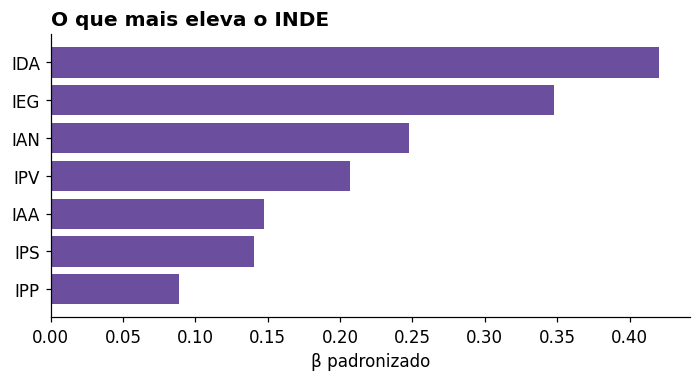

IDA    0.42
IEG    0.35
IAN    0.25
IPV    0.21
IAA    0.15
IPS    0.14
IPP    0.09
dtype: float64

In [8]:
from numpy.linalg import lstsq
d=tidy[tidy.ano==2024][['inde','ida','ieg','ips','ipp','iaa','ian','ipv']].dropna()
X=(d.drop(columns='inde')-d.drop(columns='inde').mean())/d.drop(columns='inde').std()
y=(d['inde']-d['inde'].mean())/d['inde'].std()
beta,*_=lstsq(np.c_[np.ones(len(X)),X.values],y.values,rcond=None)
pesos=pd.Series(beta[1:],index=[cc.upper() for cc in X.columns]).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(6.5,3.6)); ax.barh(pesos.index[::-1],pesos.values[::-1],color=ROXO)
ax.set_xlabel('β padronizado'); ax.set_title('O que mais eleva o INDE',loc='left',weight='bold'); plt.tight_layout(); plt.show()
pesos.round(2)

**Achado.** Maior alavancagem: **IDA + IEG** (0,42 e 0,35). Para elevar o INDE, o retorno marginal
é maior em desempenho acadêmico e engajamento.

## Q10 — Efetividade (mesma coorte de 468 alunos, sem viés de composição)

,INDE,DEFASAGEM,IDA,IEG
2022,7.38,-0.85,6.67,8.49
2023,7.36,-0.66,6.78,8.74
2024,7.38,-0.23,6.22,7.51


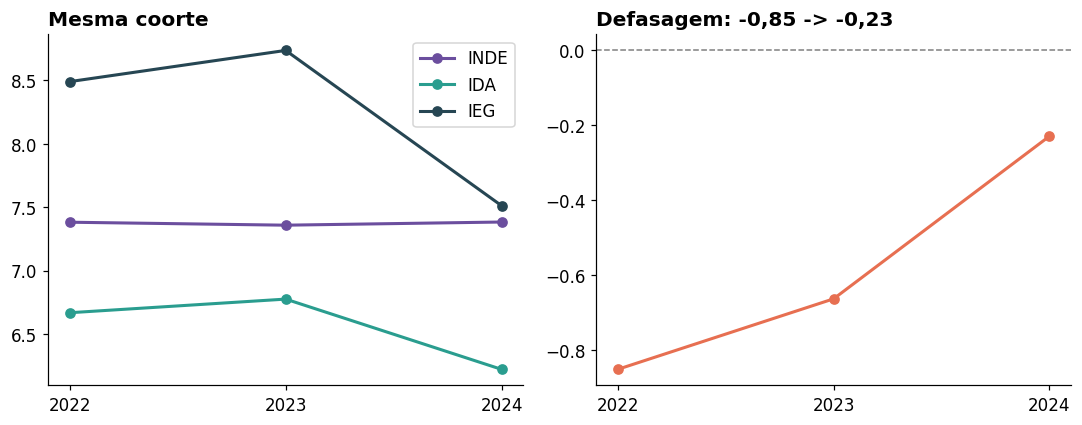

In [9]:
piv=tidy.pivot_table(index='ra',columns='ano',values=['inde','defasagem','ida','ieg'])
tres=piv.dropna(subset=[('defasagem',2022),('defasagem',2023),('defasagem',2024)]); anos=[2022,2023,2024]
display(pd.DataFrame({m.upper():[tres[(m,a)].mean() for a in anos] for m in ['inde','defasagem','ida','ieg']},index=anos).round(2))
fig,axes=plt.subplots(1,2,figsize=(10,4))
for m,cor,lab in [('inde',ROXO,'INDE'),('ida',VERDE,'IDA'),('ieg',AZUL,'IEG')]:
    axes[0].plot(anos,[tres[(m,a)].mean() for a in anos],'o-',color=cor,label=lab,lw=2)
axes[0].legend(); axes[0].set_xticks(anos); axes[0].set_title('Mesma coorte',loc='left',weight='bold')
axes[1].plot(anos,[tres[('defasagem',a)].mean() for a in anos],'o-',color=VERM,lw=2); axes[1].axhline(0,ls='--',color='gray',lw=1)
axes[1].set_xticks(anos); axes[1].set_title('Defasagem: -0,85 -> -0,23',loc='left',weight='bold'); plt.tight_layout(); plt.show()

**Achado central e honesto.** Na mesma coorte a **defasagem melhora consistentemente** (−0,85→−0,23):
o programa **fecha o gap série-idade** — impacto mais nítido. Mas o **INDE fica estável** e **IDA/IEG
recuam em 2024** — a investigar (fases mais difíceis? mudança de medição do IEG?). Rigor, não auto-elogio.

## Q11 — Insight próprio: subgrupo de risco acionável

In [10]:
m=mod[~mod.features_ausentes]
print(f"Já defasados em N -> {m[m.defasagem<0].y_risco.mean():.1%} seguem defasados (34% se recuperam)")
print(f"Em dia em N       -> {m[m.defasagem>=0].y_risco.mean():.1%} ENTRAM em defasagem ({int(m[m.defasagem>=0].y_risco.sum())} alunos)")

Já defasados em N -> 65.8% seguem defasados (34% se recuperam)
Em dia em N       -> 25.8% ENTRAM em defasagem (144 alunos)


### Síntese para o storytelling
1. O programa **fecha a defasagem série-idade** (impacto central, comprovado na mesma coorte).
2. **Engajamento e desempenho andam juntos**; autoavaliação e psicossocial são dimensões à parte.
3. **IDA + IEG** são as maiores alavancas do INDE.
4. O **Ponto de Virada** é sustentado por psicopedagógico + engajamento + desempenho.
5. Existe um **subgrupo previsível de risco** — a porta de entrada do modelo preditivo (Q9).